## Libraries

In [2]:
import math
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from keras.datasets import mnist
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier


## Task 1
Import dataset

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Task 2
Plot every number in dataset

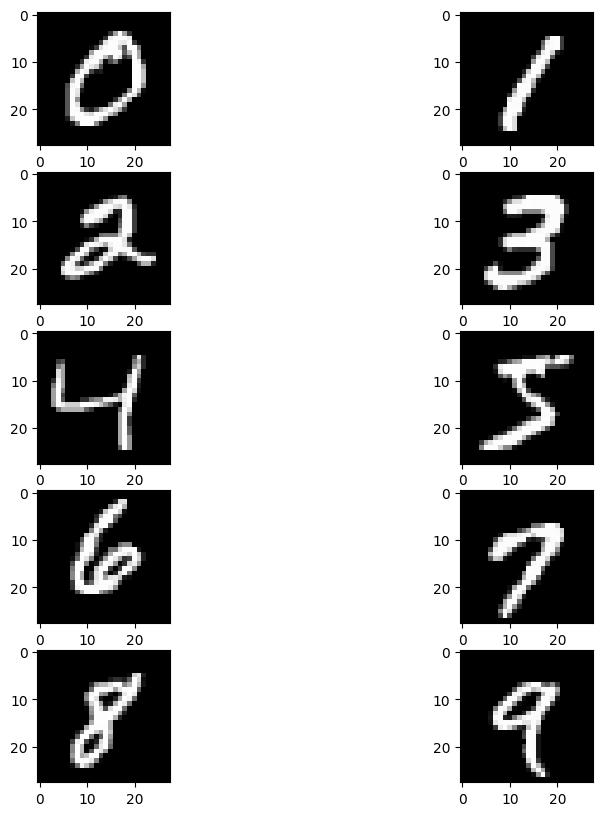

In [4]:
# Get unique values
unique_values = np.unique(y_train)

# Make subplots
fig, ax = plt.subplots(5, 2, figsize=(10, 10))

row = 0
col = 0
# For loop to print all numbers
for i, num in enumerate(unique_values):
  # Get index of every number
  idx = np.where(y_train == num)
  idx = idx[0][0]

  ax[row, col].imshow(x_train[idx], cmap='gray')


  # To make subplots counters
  col += 1
  if i == 1 or i % 2 == 1:
    row+=1
    col = 0

plt.show()


## Task 3:
What size is each image? Are all pixels of a digit image important? Explain.


### What size is each image? Are all pixels of a single-digit image important? Justify.
All images are 28*28 pixels. Every pixel is a feature and it is very important since many of the models (in this case KNN) compare images using Euclidean distance (or a different metric). That means,  even one pixel of the image changes the value of the calculation

In [5]:
x_test.shape

(10000, 28, 28)

## Task 4
Convert the images (x_train, x_test) to vectors.


### Code explanation
To reformat an image into a vector it is crusial to change the dimension and flatten the image. This can happen by reshape every image of the dataset (x_train and y_train) with shape 784 (28*28)

In [6]:
# Flatten the image
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print(f"x_train images are flatten. New shape: {x_train.shape}")
print(f"x_test images are flatten. New shape: {x_test.shape}")

x_train images are flatten. New shape: (60000, 784)
x_test images are flatten. New shape: (10000, 784)


## Task 5
Train KNN classifiers with k=5,15,51,√N , where N is the number of examples in the train set and calculate the accuracy score on the train,test sets. Then, create a line plot with k on the horizontal axis and accuracy on the vertical axis.


In [17]:
# Create a list with all nearest neighbors values
k_list = [5,15,51,int(math.sqrt(x_train.shape[0]))]


def train_model(x_train, x_test):
  # Initialize lists
  train_accuracy_list = []
  test_accuracy_list = []

  for k in k_list:
    # Initialize the model
    knn = KNeighborsClassifier(n_neighbors=k)

    # Fit the model into training set
    knn.fit(x_train, y_train)

    # Make predictions for train and test set
    train_pred_y = knn.predict(x_train)
    test_pred_y = knn.predict(x_test)

    # Calculate accuracy
    train_accuracy_list.append(accuracy_score(y_train, train_pred_y))
    test_accuracy_list.append(accuracy_score(y_test, test_pred_y))

    print(f"Model finish training for k = {k}")
  return knn, train_accuracy_list, test_accuracy_list,

# Get results
knn, train_accuracy_list, test_accuracy_list = train_model(x_train, x_test)

Model finish training for k = 5
Model finish training for k = 15
Model finish training for k = 51
Model finish training for k = 244


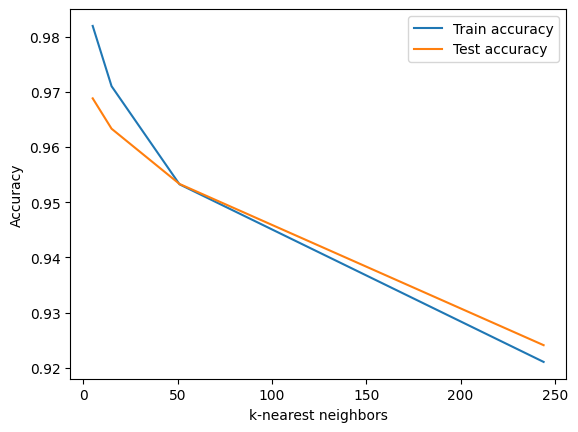

In [18]:
def plot_results(train_accuracy_list, test_accuracy_list):
  # Create two plots for train and test set
  plt.plot(k_list, train_accuracy_list, label = 'Train accuracy')
  plt.plot(k_list, test_accuracy_list, label = 'Test accuracy')

  plt.xlabel("k-nearest neighbors")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()

plot_results(train_accuracy_list, test_accuracy_list)

## Task 6
Then, divide x_train, x_test by 255 so that the pixel values ​​scale between [0, 1] and repeat question 5. Compare your results with question 5.

### Compare results
In both methods accuracy of the model decreases by using higher k value. When k value is small 3-5 then the model is able to memorize the data in a better way and it is easier for the model to get details. When the k value is high (more than 10) then the model is trained by using more neighbors which lead it to lose important details and predictions are based on the average of the pixels of the image.

Normilization technique (n/255) in most of the cases is helping the model to get better results. This is happening because of the Euclidena distance which KNN using. Instead of 0-255 model is using 0-1 values. Distances are much smaller and so it is easier and more accurate to be calculated. Without normilization high pixel values are leading into the training and small pixel values (0-20) might disappear making difficult for the model to get small details.

In this example the model got very high accuracy and there is no difference between them before and after normilization. This is happening because:
- Neighbors are not changing
- Prediction of Euclidena distance is not changing
- So accuracy stays the same (or very very close)

Since we are using KNN and the neighbors are not changing we are having the same results but in different scale.

Model finish training for k = 5
Model finish training for k = 15
Model finish training for k = 51
Model finish training for k = 244


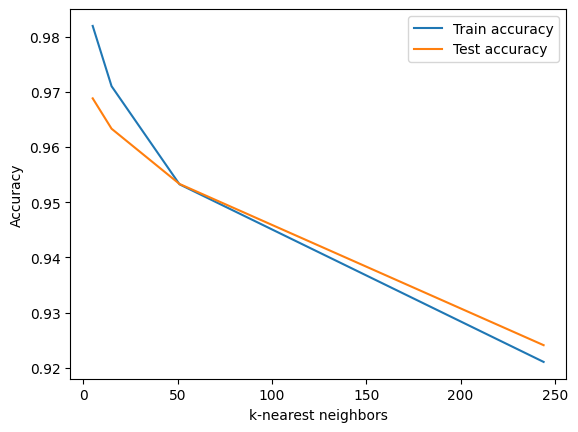

In [19]:
# Normilization
x_train = x_train/255
x_test = x_test/255

# Make training
knn, train_accuracy_list, test_accuracy_list = train_model(x_train, x_test)

# Plot results
plot_results(train_accuracy_list, test_accuracy_list)

## Task 7
Use paint to draw a digit of your choice on a 28x28 image. Specifically, place black on the background and paint the digit with white. Then, upload the image to google colab, convert it to black and white, and check if the best classifier in query 6 can correctly classify the digit.

[8]


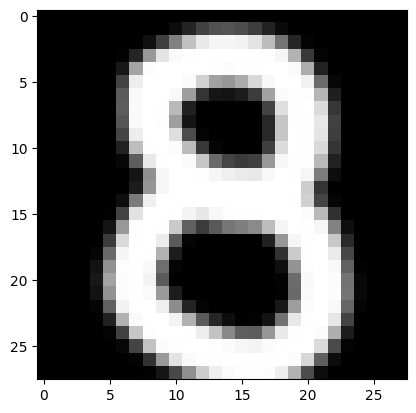

In [32]:
# Get image
image = Image.open("/content/number.png")
plt.imshow(image)

# Convert image to black and white and change it into np array
image = np.array(image.convert('L'))

image = image.reshape(-1, 784)

# Normilize image
image = image / 255

# Make prediction
print(knn.predict(image))
